# Workshop Data Pre-processing


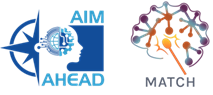

**Objectives:**


*   Get acquainted with the workshop dataset
*   Perform simple data imputation and encoding
* Work with scikit-learn objects such as estimators and transformers



**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Predictive modeling using healthcare data. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenter and Code Author: Mignon Dumanjog, M.S., University of Texas at San Antonio<br>

# Import packages & data

You can either load the data from Kaggle (through an API token which can be obtained from your Kaggle settings page), or from local files by uploading *train.csv*, *test.csv*, and *solution.csv* from the [aiMATCH GitHub page.](https://github.com/qutublab/aiMATCH/releases/tag/Predictive-modeling-workshop)<br>Run the cell corresponding to your chosen method.

In [ ]:
import numpy as np
import pandas as pd
import os

*From Kaggle*

In [ ]:
# NEVER SHARE YOUR API TOKEN PUBLICLY.
# Tip: Store your API token as a Secret in Google Colab.
# If running locally, do not commit your .env file or it will expose secrets
# that will allow others to control access to your various AI and authentication provider accounts.
import kagglehub
kagglehub.login()

aimatch_workshop_predicting_health_outcomes_path = kagglehub.competition_download('aimatch-workshop-predicting-health-outcomes')

print('Data source import complete.')

train_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Train.csv'))
test_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Test.csv'))
solution_df = test_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Solution.csv'))


100%|██████████| 5.13k/5.13k [00:00<00:00, 4.14MB/s]

Extracting files...
Data source import complete.


Kaggle credentials set.
Kaggle credentials successfully validated.


*From files*

In [ ]:
train_df = pd.read_csv('/path/Train.csv') # change to actual path
test_df = pd.read_csv('/path/Test.csv') # change to actual path
solution_df = test_df = pd.read_csv('/path/Solution.csv') # change to actual path

Let's start by loading the training and test sets.

In [ ]:
display(train_df)

,UPIN,FAB.(Assigned),Age.Dx,Age.subgroup,Weight.kg,BMI,HCT,Dysplasia,Protein A,Protein B,Protein C,Response Simple
0,1000035,M1,71,>60,85.776644,27.776902,26.731212,N,0.852484,0.159452,0.037960,NR
1,1000036,M2,66,>60,NaN,NaN,22.465783,Y,0.029332,2.189474,-0.172768,NR
2,1000037,M1,67,>60,90.369904,30.931397,24.609346,NaN,1.097309,3.191191,0.345861,NR
3,1000038,M2,75,>60,90.044800,27.683778,27.044033,NaN,0.459172,1.175251,-0.135354,NR
4,1000039,NaN,69,>60,52.506811,22.331167,23.920122,NaN,0.529991,1.473436,0.331639,CR/CRI
...,...,...,...,...,...,...,...,...,...,...,...,...
61,1000096,M5,32,18-40,66.905671,23.311542,28.018301,NaN,0.172368,0.677556,-0.076382,CR/CRI
62,1000097,M1,50,41-60,99.723615,27.184373,29.436481,NaN,-0.137950,1.295396,0.074580,CR/CRI
63,1000098,M2,60,>60,103.352203,30.142356,31.755361,Y,0.860803,1.827270,0.360932,CR/CRI
64,1000099,M2,57,>60,54.759623,26.464954,35.720076,Y,0.300009,1.090787,-0.148951,NR


In [ ]:
display(test_df)

,UPIN,FAB.(Assigned),Age.Dx,Age.subgroup,Weight.kg,BMI,HCT,Dysplasia,Protein A,Protein B,Protein C
0,1000001,M5,54,41-60,71.752459,26.299018,26.426160,Y,0.315229,1.787720,-0.031596
1,1000002,M2,41,18-40,91.017163,26.708212,30.177118,NaN,0.747909,1.083199,0.020192
2,1000003,M1,68,>60,105.894574,36.522826,23.147222,NaN,1.051150,0.918774,-0.116739
3,1000004,M2,46,41-60,71.782015,25.667771,30.020232,Y,2.197773,5.883803,0.177127
4,1000005,M5,72,>60,89.827215,34.089594,32.411026,Y,0.471058,1.903025,-0.158784
5,1000006,M1,78,>60,NaN,NaN,26.250389,Y,0.593463,1.687276,-0.346828
6,1000007,M0,79,>60,70.271958,28.872414,32.344074,Y,0.321210,1.305064,-0.025982
7,1000008,M1,69,>60,43.091196,19.432546,24.807721,N,2.257387,0.988967,0.346407
8,1000009,M2,28,18-40,103.829615,34.828592,26.965965,Y,-0.106215,0.711142,-0.114509
9,1000010,M1,57,41-60,52.434427,20.643621,27.912762,NaN,-0.502480,0.638144,-0.022314


Next, we'll separate the features and labels, then load the test set.

In [ ]:
X_train = train_df.iloc[:,1:-1]
y_train = train_df.iloc[:,-1]
y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)
X_test = test_df
display(X_train)
display(y_train)

/tmp/ipykernel_55/176422569.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)


,FAB.(Assigned),Age.Dx,Age.subgroup,Weight.kg,BMI,HCT,Dysplasia,Protein A,Protein B,Protein C
0,M1,71,>60,85.776644,27.776902,26.731212,N,0.852484,0.159452,0.037960
1,M2,66,>60,NaN,NaN,22.465783,Y,0.029332,2.189474,-0.172768
2,M1,67,>60,90.369904,30.931397,24.609346,NaN,1.097309,3.191191,0.345861
3,M2,75,>60,90.044800,27.683778,27.044033,NaN,0.459172,1.175251,-0.135354
4,NaN,69,>60,52.506811,22.331167,23.920122,NaN,0.529991,1.473436,0.331639
...,...,...,...,...,...,...,...,...,...,...
61,M5,32,18-40,66.905671,23.311542,28.018301,NaN,0.172368,0.677556,-0.076382
62,M1,50,41-60,99.723615,27.184373,29.436481,NaN,-0.137950,1.295396,0.074580
63,M2,60,>60,103.352203,30.142356,31.755361,Y,0.860803,1.827270,0.360932
64,M2,57,>60,54.759623,26.464954,35.720076,Y,0.300009,1.090787,-0.148951


0     0
1     0
2     0
3     0
4     1
     ..
61    1
62    1
63    1
64    0
65    0
Name: Response Simple, Length: 66, dtype: int64

Identify numeric and categorical features based on their pandas data types.

In [ ]:
def id_str_and_cat_cols(df):
    num_cols = []
    cat_cols = []
    for col_name in df.columns:
        print(col_name, df[col_name].dtype)
        print("-" * 20)

        if df[col_name].dtype in['int64','float64']:
            num_cols.append(df[col_name].name)
        else:
            cat_cols.append(df[col_name].name)
    return num_cols, cat_cols
            # print(df[col_name].name)

numeric_features, categorical_features = id_str_and_cat_cols(X_train)

FAB.(Assigned) object
--------------------
Age.Dx int64
--------------------
Age.subgroup object
--------------------
Weight.kg float64
--------------------
BMI float64
--------------------
HCT float64
--------------------
Dysplasia object
--------------------
Protein A float64
--------------------
Protein B float64
--------------------
Protein C float64
--------------------


Define the numeric preprocessing pipeline that: <br>
1. Imputes missing values using the median (robust to outliers)

2. Standardizes features to have zero mean and unit variance

In [ ]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')),
        ("scaler", StandardScaler())
    ]
)

In [ ]:
display(train_df[numeric_features])

,Age.Dx,Weight.kg,BMI,HCT,Protein A,Protein B,Protein C
0,71,85.776644,27.776902,26.731212,0.852484,0.159452,0.037960
1,66,NaN,NaN,22.465783,0.029332,2.189474,-0.172768
2,67,90.369904,30.931397,24.609346,1.097309,3.191191,0.345861
3,75,90.044800,27.683778,27.044033,0.459172,1.175251,-0.135354
4,69,52.506811,22.331167,23.920122,0.529991,1.473436,0.331639
...,...,...,...,...,...,...,...
61,32,66.905671,23.311542,28.018301,0.172368,0.677556,-0.076382
62,50,99.723615,27.184373,29.436481,-0.137950,1.295396,0.074580
63,60,103.352203,30.142356,31.755361,0.860803,1.827270,0.360932
64,57,54.759623,26.464954,35.720076,0.300009,1.090787,-0.148951


In [ ]:
Xt_num = numeric_transformer.fit_transform(X_train[numeric_features])
print(Xt_num.shape)
Xt_num_df = pd.DataFrame(
    Xt_num,
    columns=numeric_features
)
display(Xt_num_df)

(66, 7)


,Age.Dx,Weight.kg,BMI,HCT,Protein A,Protein B,Protein C
0,0.748076,0.056415,-0.205500,0.038392,0.706803,-1.041772,0.189591
1,0.397416,0.027703,-0.219316,-0.920606,-0.853227,0.509397,-0.542929
2,0.467548,0.282613,0.262492,-0.438667,1.170792,1.274824,1.259898
3,1.028605,0.266603,-0.219316,0.108724,-0.038599,-0.265585,-0.412872
4,0.607812,-1.581986,-1.013413,-0.593626,0.095617,-0.037737,1.210461
...,...,...,...,...,...,...,...
61,-1.987078,-0.872902,-0.867968,0.327769,-0.582147,-0.645881,-0.207877
62,-0.724699,0.743245,-0.293406,0.646619,-1.170258,-0.173780,0.316889
63,-0.023377,0.921937,0.145432,1.167974,0.722568,0.232632,1.312287
64,-0.233774,-1.471044,-0.400137,2.059362,-0.340242,-0.330125,-0.460139


Define the categorical preprocessing pipeline that:

1. Imputes missing values using the most frequent category

2. Encodes categories using one-hot encoding

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
Xt_cat = categorical_transformer.fit_transform(X_train[categorical_features])
print(Xt_cat)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 198 stored elements and shape (66, 10)>
  Coords	Values
  (0, 1)	1.0
  (0, 7)	1.0
  (0, 8)	1.0
  (1, 2)	1.0
  (1, 7)	1.0
  (1, 9)	1.0
  (2, 1)	1.0
  (2, 7)	1.0
  (2, 9)	1.0
  (3, 2)	1.0
  (3, 7)	1.0
  (3, 9)	1.0
  (4, 2)	1.0
  (4, 7)	1.0
  (4, 9)	1.0
  (5, 3)	1.0
  (5, 7)	1.0
  (5, 9)	1.0
  (6, 1)	1.0
  (6, 5)	1.0
  (6, 9)	1.0
  (7, 2)	1.0
  (7, 7)	1.0
  (7, 9)	1.0
  (8, 3)	1.0
  :	:
  (57, 9)	1.0
  (58, 2)	1.0
  (58, 7)	1.0
  (58, 8)	1.0
  (59, 2)	1.0
  (59, 5)	1.0
  (59, 9)	1.0
  (60, 0)	1.0
  (60, 5)	1.0
  (60, 9)	1.0
  (61, 3)	1.0
  (61, 5)	1.0
  (61, 9)	1.0
  (62, 1)	1.0
  (62, 6)	1.0
  (62, 9)	1.0
  (63, 2)	1.0
  (63, 7)	1.0
  (63, 9)	1.0
  (64, 2)	1.0
  (64, 7)	1.0
  (64, 9)	1.0
  (65, 3)	1.0
  (65, 7)	1.0
  (65, 9)	1.0


Finally, we combine the numeric and categorical preprocessing pipelines using a ColumnTransformer.
This ensures that each feature type receives the correct preprocessing steps within a single unified workflow, which is essential for reproducibility and preventing data leakage during model training and cross-validation.

In [ ]:
ohe = categorical_transformer.named_steps["onehot"]

feature_names = ohe.get_feature_names_out(categorical_features)

Xt_cat_df = pd.DataFrame(
    Xt_cat.toarray(),
    columns=feature_names
)

print(Xt_cat_df)

    FAB.(Assigned)_M0  FAB.(Assigned)_M1  FAB.(Assigned)_M2  \
0                 0.0                1.0                0.0   
1                 0.0                0.0                1.0   
2                 0.0                1.0                0.0   
3                 0.0                0.0                1.0   
4                 0.0                0.0                1.0   
..                ...                ...                ...   
61                0.0                0.0                0.0   
62                0.0                1.0                0.0   
63                0.0                0.0                1.0   
64                0.0                0.0                1.0   
65                0.0                0.0                0.0   

    FAB.(Assigned)_M5  FAB.(Assigned)_M6  Age.subgroup_18-40  \
0                 0.0                0.0                 0.0   
1                 0.0                0.0                 0.0   
2                 0.0                0.0           

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
Xt_all_cols = pd.DataFrame(preprocessor.fit_transform(X_train))
Xt_all_cols.columns = np.append(Xt_num_df.columns.to_numpy(), Xt_cat_df.columns.to_numpy())
display(Xt_all_cols)

,Age.Dx,Weight.kg,BMI,HCT,Protein A,Protein B,Protein C,FAB.(Assigned)_M0,FAB.(Assigned)_M1,FAB.(Assigned)_M2,FAB.(Assigned)_M5,FAB.(Assigned)_M6,Age.subgroup_18-40,Age.subgroup_41-60,Age.subgroup_>60,Dysplasia_N,Dysplasia_Y
0,0.748076,0.056415,-0.205500,0.038392,0.706803,-1.041772,0.189591,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.397416,0.027703,-0.219316,-0.920606,-0.853227,0.509397,-0.542929,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.467548,0.282613,0.262492,-0.438667,1.170792,1.274824,1.259898,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.028605,0.266603,-0.219316,0.108724,-0.038599,-0.265585,-0.412872,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.607812,-1.581986,-1.013413,-0.593626,0.095617,-0.037737,1.210461,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,-1.987078,-0.872902,-0.867968,0.327769,-0.582147,-0.645881,-0.207877,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
62,-0.724699,0.743245,-0.293406,0.646619,-1.170258,-0.173780,0.316889,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
63,-0.023377,0.921937,0.145432,1.167974,0.722568,0.232632,1.312287,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
64,-0.233774,-1.471044,-0.400137,2.059362,-0.340242,-0.330125,-0.460139,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
